##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.


In [1]:
import os
import cv2
import math
import random
import numpy as np
import datetime as dt
import tensorflow as tf
from moviepy.editor import *
from collections import deque
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



In [2]:
seed_constant = 23
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)


In [7]:
import zipfile
import os

zip_file_path = "/content/action_youtube_naudio_3classes.zip"
extract_directory = "/content"

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_directory)

print(os.listdir("/content"))
print(os.listdir("/content/action_youtube_naudio_3classes"))


['.config', 'action_youtube_naudio_3classes', 'tennis_swing_Video.mp4', 'Basketball_Video.mp4', 'Walking_Video.mp4', 'action_youtube_naudio_3classes.zip', 'sample_data']
['walking', 'basketball', 'tennis_swing']


In [8]:
dataset_directory = "/content/action_youtube_naudio_3classes"
classes_list = ["basketball", "walking", "tennis_swing"]

model_output_size = len(classes_list)


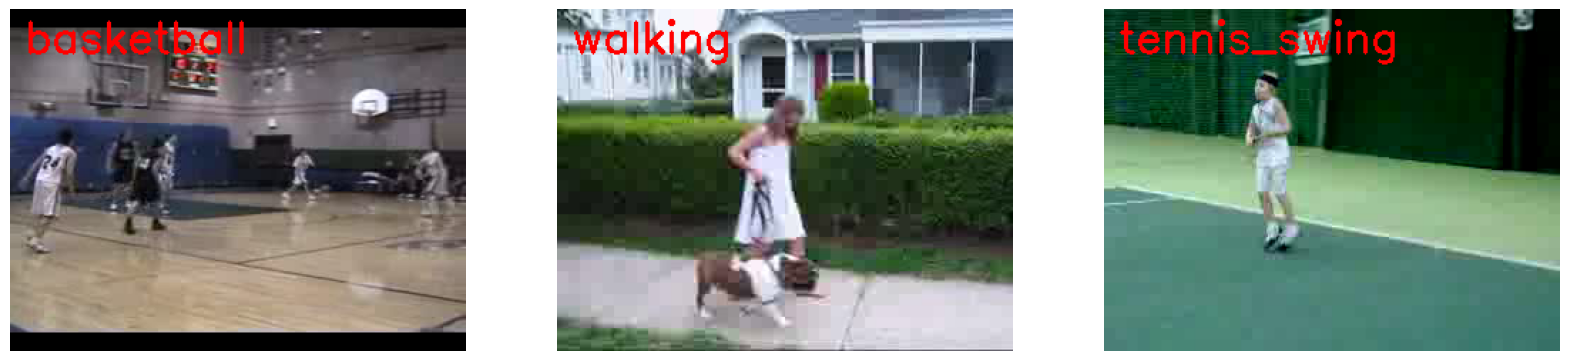

In [9]:
plt.figure(figsize = (20, 20))

all_classes_names = classes_list

for counter, selected_class_name in enumerate(all_classes_names, 1):

    class_directory = os.path.join(dataset_directory, selected_class_name)
    class_sub_directories = [directory_name for directory_name in os.listdir(class_directory) if os.path.isdir(os.path.join(class_directory, directory_name)) and directory_name != 'Annotation']

    selected_sub_directory = random.choice(class_sub_directories)
    selected_sub_directory_path = os.path.join(class_directory, selected_sub_directory)

    video_files_names_list = [file_name for file_name in os.listdir(selected_sub_directory_path) if file_name.lower().endswith('.avi')]

    selected_video_file_name = random.choice(video_files_names_list)

    video_reader = cv2.VideoCapture(os.path.join(selected_sub_directory_path, selected_video_file_name))
    success, bgr_frame = video_reader.read()

    video_reader.release()

    if not success:
        continue

    rgb_frame = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)

    cv2.putText(rgb_frame, selected_class_name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

    plt.subplot(1, 3, counter)
    plt.imshow(rgb_frame)
    plt.axis('off')


In [10]:
image_height, image_width = 64, 64
max_images_per_class = 8000


In [11]:
def frames_extraction(video_path):
    frames_list = []

    video_reader = cv2.VideoCapture(video_path)

    while True:

        success, frame = video_reader.read()

        if not success:
            break

        resized_frame = cv2.resize(frame, (image_height, image_width))

        normalized_frame = resized_frame / 255

        frames_list.append(normalized_frame)

    video_reader.release()

    return frames_list


In [12]:
def create_dataset():

    temp_features = []
    features = []
    labels = []

    for class_index, class_name in enumerate(classes_list):
        print(f'Extracting Data of Class: {class_name}')

        class_directory = os.path.join(dataset_directory, class_name)
        sub_directories_list = os.listdir(class_directory)

        for sub_directory in sub_directories_list:

            if sub_directory == 'Annotation':
                continue

            sub_directory_path = os.path.join(class_directory, sub_directory)

            if not os.path.isdir(sub_directory_path):
                continue

            files_list = os.listdir(sub_directory_path)

            for file_name in files_list:

                if not file_name.lower().endswith('.avi'):
                    continue

                video_file_path = os.path.join(sub_directory_path, file_name)

                frames = frames_extraction(video_file_path)

                temp_features.extend(frames)

        selected_features = random.sample(temp_features, min(max_images_per_class, len(temp_features)))

        features.extend(selected_features)

        labels.extend([class_index] * len(selected_features))

        temp_features.clear()

    features = np.asarray(features)
    labels = np.array(labels)

    return features, labels


In [13]:
features, labels = create_dataset()


Extracting Data of Class: basketball
Extracting Data of Class: walking
Extracting Data of Class: tennis_swing


In [14]:
one_hot_encoded_labels = to_categorical(labels)


In [15]:
features_train, features_test, labels_train, labels_test = train_test_split(features, one_hot_encoded_labels, test_size = 0.2, shuffle = True, random_state = seed_constant)


In [16]:
def create_model():

    model = Sequential()

    model.add(Conv2D(filters = 64, kernel_size = (3, 3), activation = 'relu', input_shape = (image_height, image_width, 3)))
    model.add(Conv2D(filters = 64, kernel_size = (3, 3), activation = 'relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size = (2, 2)))
    model.add(GlobalAveragePooling2D())
    model.add(Dense(256, activation = 'relu'))
    model.add(BatchNormalization())
    model.add(Dense(model_output_size, activation = 'softmax'))

    model.summary()

    return model


model = create_model()

print("Model Created Successfully!")


  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,411 (224.26 KB)

 Trainable params: 56,771 (221.76 KB)

 Non-trainable params: 640 (2.50 KB)

Model Created Successfully!


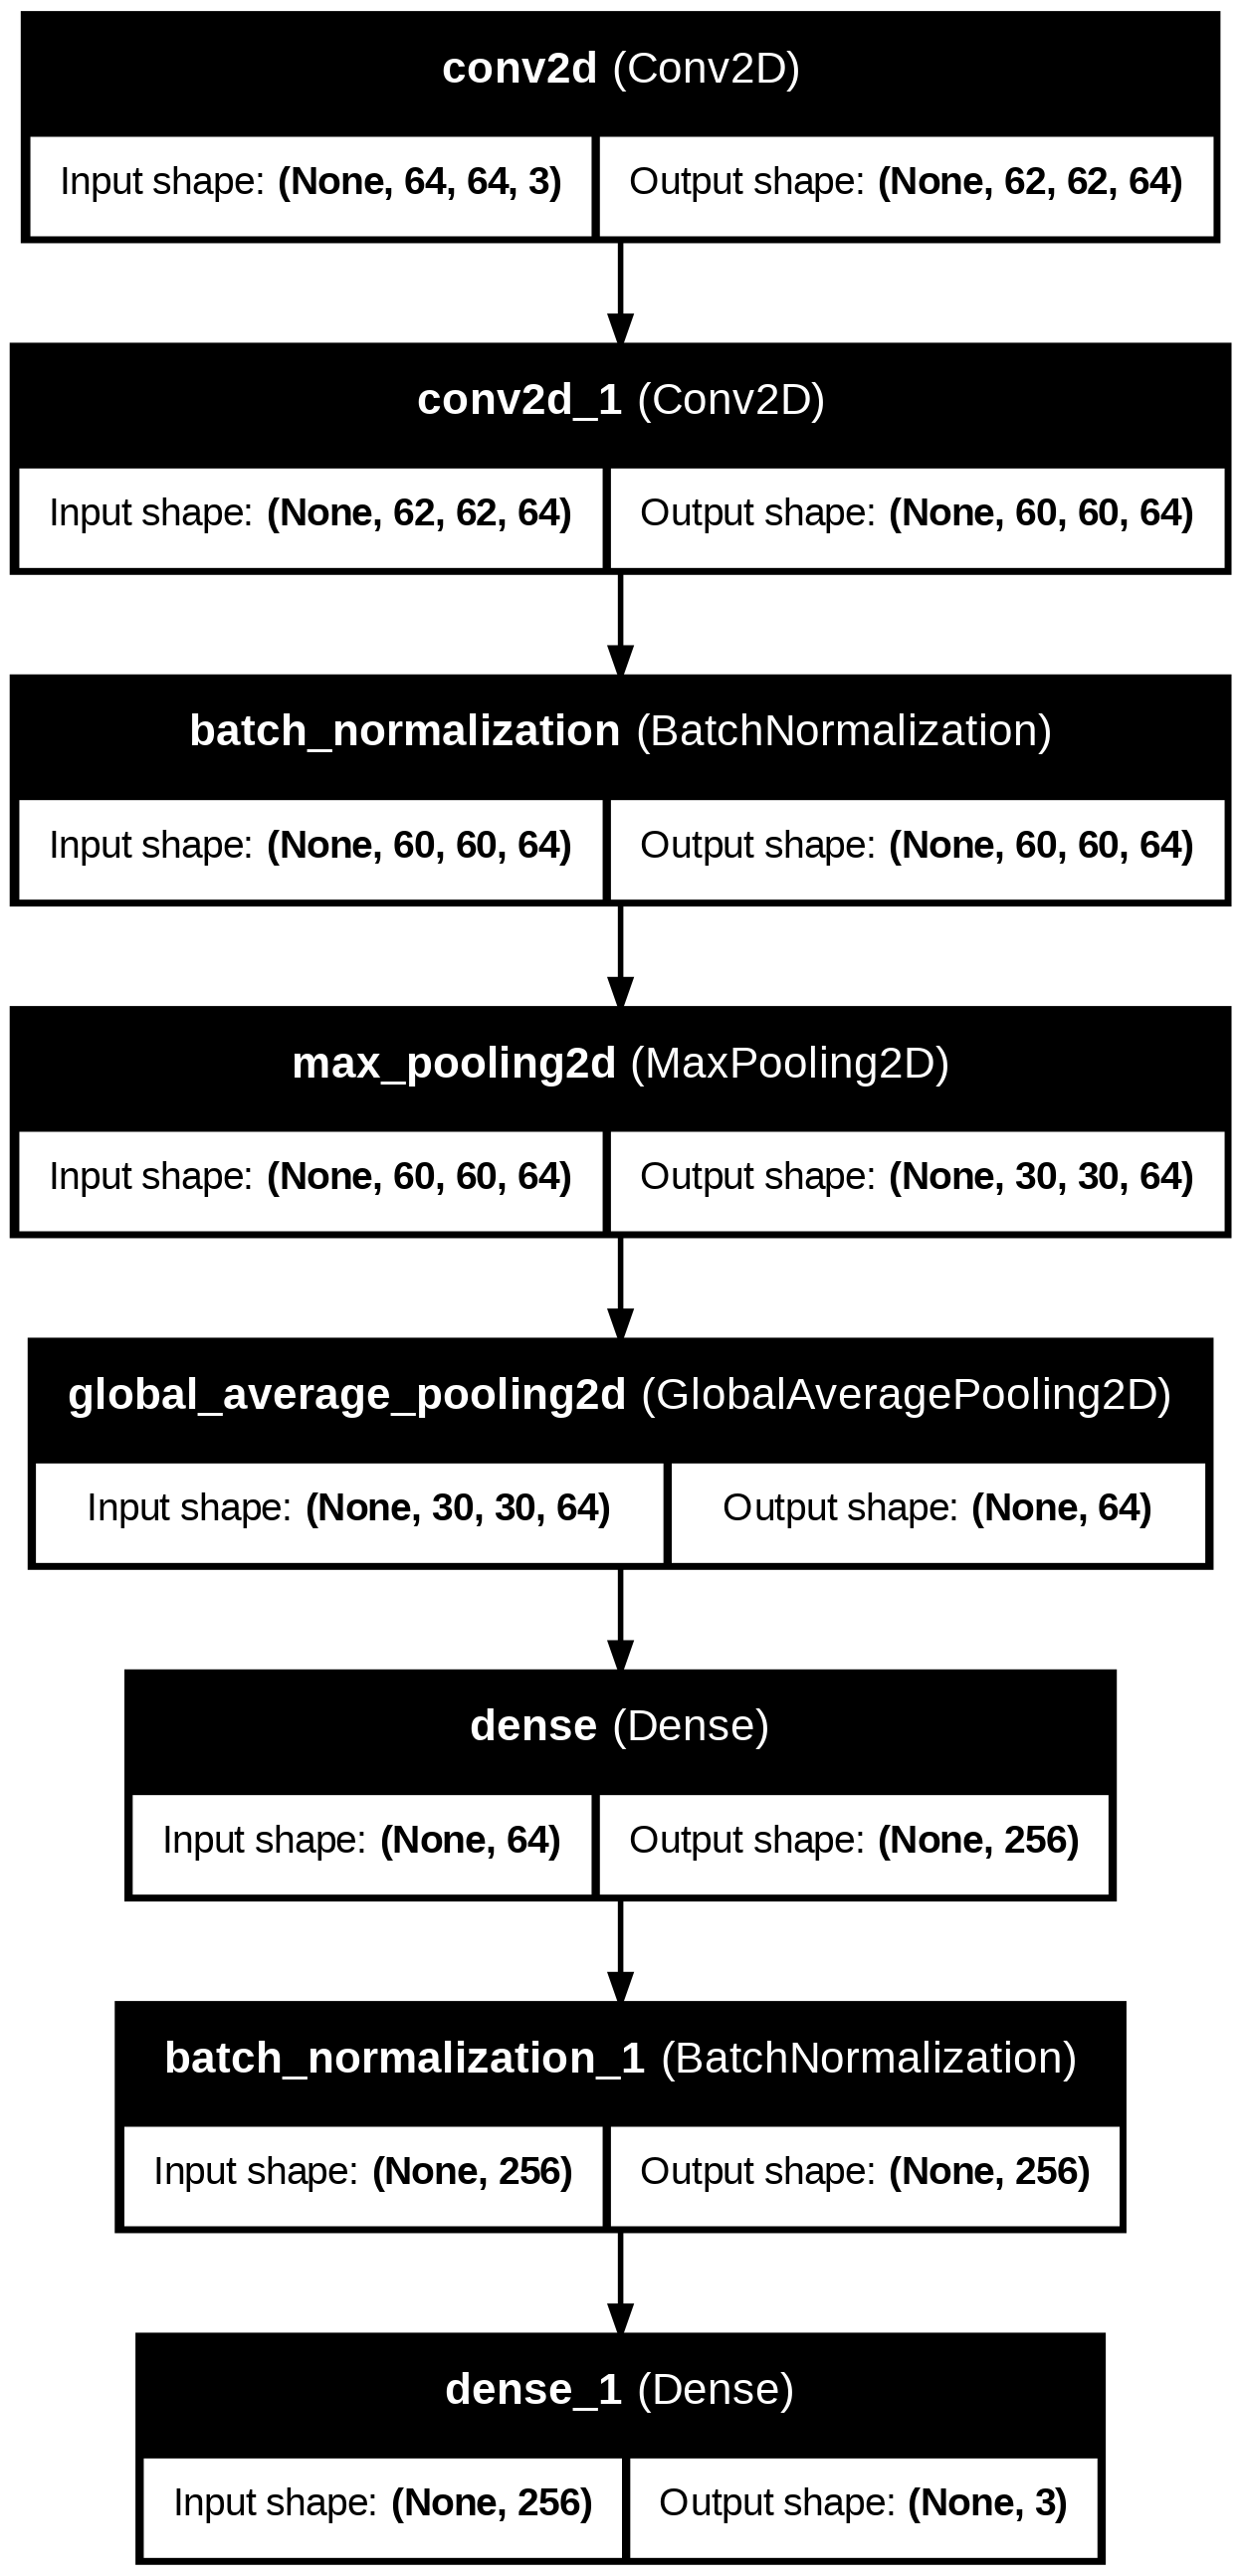

In [17]:
plot_model(model, to_file = 'model_structure_plot.png', show_shapes = True, show_layer_names = True)


In [18]:
early_stopping_callback = EarlyStopping(monitor = 'val_loss', patience = 15, mode = 'min', restore_best_weights = True)

model.compile(loss = 'categorical_crossentropy', optimizer = 'Adam', metrics = ["accuracy"])

model_training_history = model.fit(x = features_train, y = labels_train, epochs = 5, batch_size = 4, shuffle = True, validation_split = 0.2, callbacks = [early_stopping_callback])


Epoch 1/5
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - accuracy: 0.6547 - loss: 0.7733 - val_accuracy: 0.7935 - val_loss: 0.5267
Epoch 2/5
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.8236 - loss: 0.4576 - val_accuracy: 0.8583 - val_loss: 0.3881
Epoch 3/5
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.8720 - loss: 0.3494 - val_accuracy: 0.9326 - val_loss: 0.1831
Epoch 4/5
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.8983 - loss: 0.2879 - val_accuracy: 0.9763 - val_loss: 0.0695
Epoch 5/5
3840/3840 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9169 - loss: 0.2404 - val_accuracy: 0.8854 - val_loss: 0.4180


In [19]:
model_evaluation_history = model.evaluate(features_test, labels_test)


150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9721 - loss: 0.0819


In [20]:
student_name = "Fatima_Alawami"

date_time_format = '%Y_%m_%d__%H_%M_%S'
current_date_time_dt = dt.datetime.now()
current_date_time_string = dt.datetime.strftime(current_date_time_dt, date_time_format)
model_evaluation_loss, model_evaluation_accuracy = model_evaluation_history
model_name = f'{student_name}_ucf11_model___Date_Time_{current_date_time_string}___Loss_{model_evaluation_loss}___Accuracy_{model_evaluation_accuracy}.h5'

model.save(model_name)
print(f"Model saved as {model_name}")


Model saved as Fatima_Alawami_ucf11_model___Date_Time_2026_05_03__18_41_11___Loss_0.08188801258802414___Accuracy_0.972083330154419.h5


In [21]:
def plot_metric(metric_name_1, metric_name_2, plot_name):
  metric_value_1 = model_training_history.history[metric_name_1]
  metric_value_2 = model_training_history.history[metric_name_2]

  epochs = range(len(metric_value_1))

  plt.plot(epochs, metric_value_1, 'blue', label = metric_name_1)
  plt.plot(epochs, metric_value_2, 'red', label = metric_name_2)

  plt.title(str(plot_name))

  plt.legend()


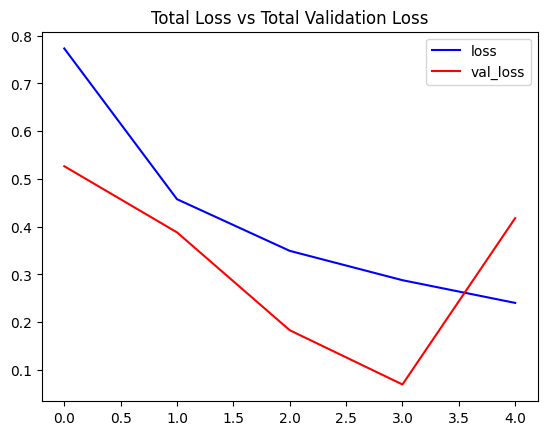

In [22]:
plot_metric('loss', 'val_loss', 'Total Loss vs Total Validation Loss')


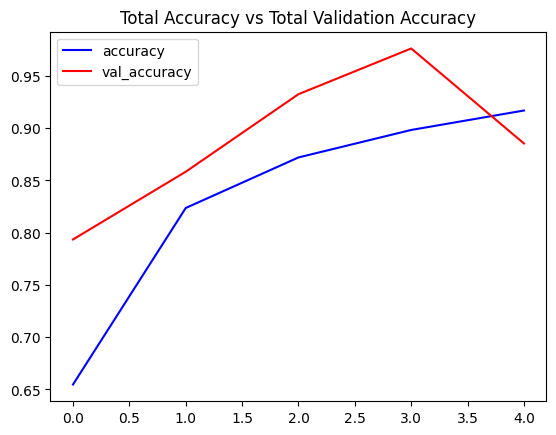

In [23]:
plot_metric('accuracy', 'val_accuracy', 'Total Accuracy vs Total Validation Accuracy')


In [24]:
def predict_on_live_video(video_file_path, output_file_path, window_size):

    predicted_labels_probabilities_deque = deque(maxlen = window_size)

    video_reader = cv2.VideoCapture(video_file_path)

    original_video_width = int(video_reader.get(cv2.CAP_PROP_FRAME_WIDTH))
    original_video_height = int(video_reader.get(cv2.CAP_PROP_FRAME_HEIGHT))

    video_writer = cv2.VideoWriter(output_file_path, cv2.VideoWriter_fourcc('M', 'P', '4', 'V'), 24, (original_video_width, original_video_height))

    while True:

        status, frame = video_reader.read()

        if not status:
            break

        resized_frame = cv2.resize(frame, (image_height, image_width))

        normalized_frame = resized_frame / 255

        predicted_labels_probabilities = model.predict(np.expand_dims(normalized_frame, axis = 0), verbose = 0)[0]

        predicted_labels_probabilities_deque.append(predicted_labels_probabilities)

        if len(predicted_labels_probabilities_deque) == window_size:

            predicted_labels_probabilities_np = np.array(predicted_labels_probabilities_deque)

            predicted_labels_probabilities_averaged = predicted_labels_probabilities_np.mean(axis = 0)

            predicted_label = np.argmax(predicted_labels_probabilities_averaged)

            predicted_class_name = classes_list[predicted_label]

            cv2.putText(frame, predicted_class_name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

        video_writer.write(frame)

    video_reader.release()
    video_writer.release()


In [25]:
def make_average_predictions(video_file_path, predictions_frames_count):

    predicted_labels_probabilities_np = np.zeros((predictions_frames_count, model_output_size), dtype = float)

    video_reader = cv2.VideoCapture(video_file_path)

    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))

    skip_frames_window = max(video_frames_count // predictions_frames_count, 1)

    for frame_counter in range(predictions_frames_count):

        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)

        success, frame = video_reader.read()

        if not success:
            break

        resized_frame = cv2.resize(frame, (image_height, image_width))

        normalized_frame = resized_frame / 255

        predicted_labels_probabilities = model.predict(np.expand_dims(normalized_frame, axis = 0), verbose = 0)[0]

        predicted_labels_probabilities_np[frame_counter] = predicted_labels_probabilities

    predicted_labels_probabilities_averaged = predicted_labels_probabilities_np.mean(axis = 0)

    predicted_labels_probabilities_averaged_sorted_indexes = np.argsort(predicted_labels_probabilities_averaged)[::-1]

    for predicted_label in predicted_labels_probabilities_averaged_sorted_indexes:

        predicted_class_name = classes_list[predicted_label]

        predicted_probability = predicted_labels_probabilities_averaged[predicted_label]

        print(f"CLASS NAME: {predicted_class_name:<15} AVERAGED PROBABILITY: {predicted_probability:.2f}")

    video_reader.release()


In [26]:
output_directory = 'Youtube_Videos'
os.makedirs(output_directory, exist_ok = True)

youtube_videos_urls = {
    'basketball': '/content/Basketball_Video.mp4',
    'walking': '/content/Walking_Video.mp4',
    'tennis_swing': '/content/tennis_swing_Video.mp4'
}


In [27]:
window_size = 25

for video_title, input_video_file_path in youtube_videos_urls.items():

    if input_video_file_path == '':
        continue

    output_video_file_path = f'{output_directory}/{video_title} -Output-WSize {window_size}.mp4'

    predict_on_live_video(input_video_file_path, output_video_file_path, window_size)


In [28]:
for video_title, input_video_file_path in youtube_videos_urls.items():

    if input_video_file_path == '':
        continue

    print(f'Predictions for {video_title}:')
    make_average_predictions(input_video_file_path, 50)
    print()


Predictions for basketball:
CLASS NAME: walking         AVERAGED PROBABILITY: 0.77
CLASS NAME: tennis_swing    AVERAGED PROBABILITY: 0.16
CLASS NAME: basketball      AVERAGED PROBABILITY: 0.07

Predictions for walking:
CLASS NAME: basketball      AVERAGED PROBABILITY: 0.93
CLASS NAME: walking         AVERAGED PROBABILITY: 0.07
CLASS NAME: tennis_swing    AVERAGED PROBABILITY: 0.00

Predictions for tennis_swing:
CLASS NAME: walking         AVERAGED PROBABILITY: 1.00
CLASS NAME: basketball      AVERAGED PROBABILITY: 0.00
CLASS NAME: tennis_swing    AVERAGED PROBABILITY: 0.00

